In [5]:
pip install notebook jupyterlab

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step

HYBRID ACCURACY: 0.7545
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00        24
      Backdoor       0.00      0.00      0.00        24
           DoS       0.21      0.07      0.10       131
      Exploits       0.57      0.66      0.61       396
       Fuzzers       0.68      0.50      0.58       214
       Generic       0.78      0.98      0.87       462
        Normal       1.00      1.00      1.00       628
Reconnaissance       0.39      0.49      0.44       107
     Shellcode       0.00      0.00      0.00        13
         Worms       0.00      0.00      0.00         1

      accuracy                           0.75      2000
     macro avg       0.36      0.37      0.36      2000
  weighted avg       0.71      0.75      0.73      2000



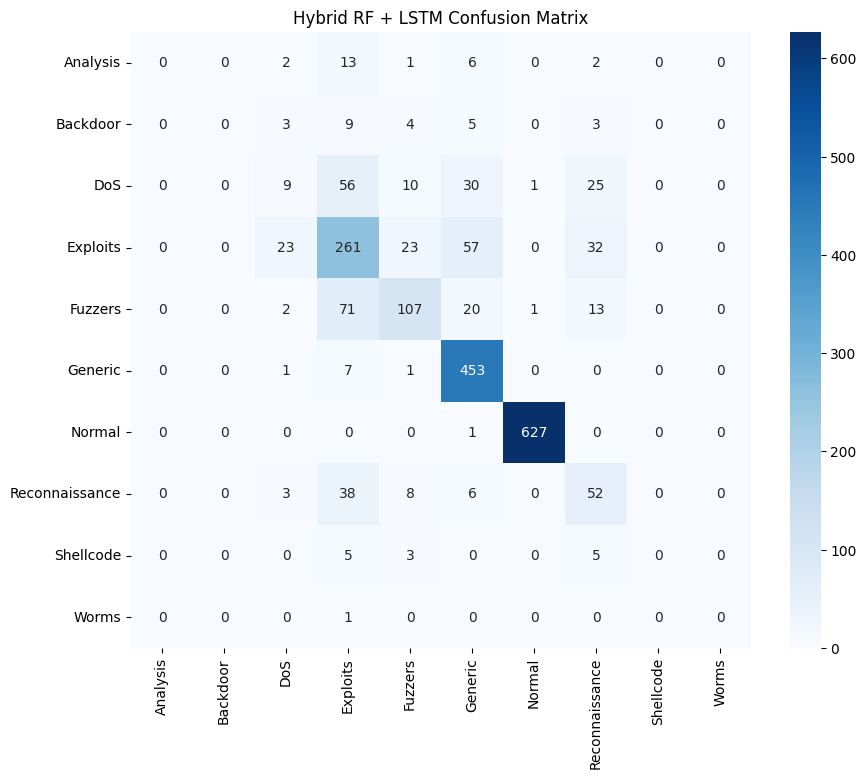

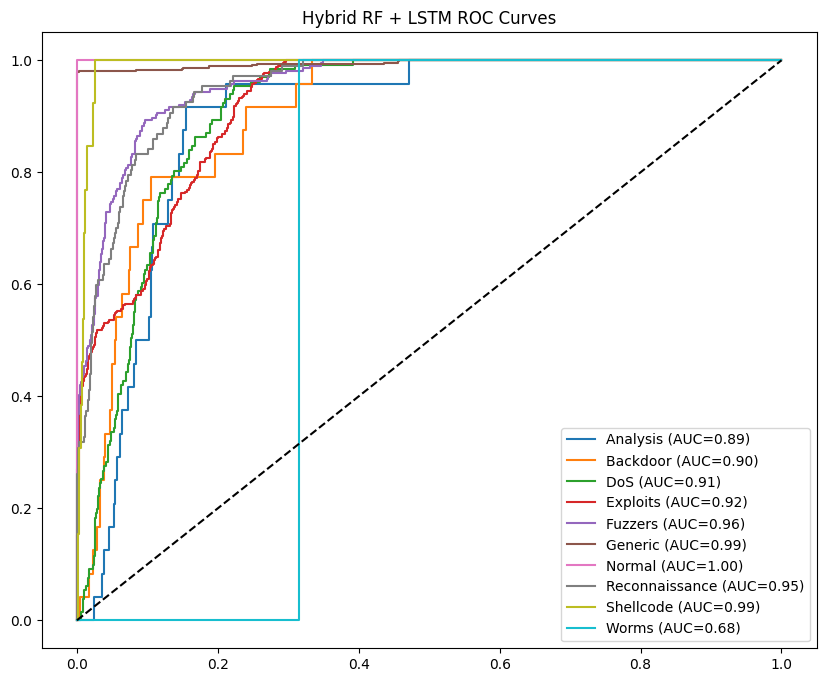

In [6]:
# ===================== COMPLETE HYBRID RF + LSTM IDS (ONE CELL) =====================

# ---------------- IMPORTS ----------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# ---------------- CONFIG ----------------
TRAIN_PATH = "datasets/UNSW_NB15_training-set.csv"
TEST_PATH  = "datasets/UNSW_NB15_testing-set.csv"
FAST_MODE = True
RANDOM_STATE = 42

# ---------------- LOAD DATA ----------------
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

if FAST_MODE:
    train_df = train_df.sample(5000, random_state=RANDOM_STATE)
    test_df  = test_df.sample(2000, random_state=RANDOM_STATE)

# ---------------- LABEL ENCODING (SAFE) ----------------
LABEL_COL = "attack_cat"

train_labels = sorted(train_df[LABEL_COL].astype(str).unique())
label_to_id = {l:i for i,l in enumerate(train_labels)}

y_train = train_df[LABEL_COL].astype(str).map(label_to_id)
y_test_raw = test_df[LABEL_COL].astype(str)
y_test = y_test_raw.map(label_to_id)

mask = y_test.notna()
test_df = test_df.loc[mask].reset_index(drop=True)
y_test = y_test.loc[mask].astype(int)

# ---------------- FEATURES ----------------
X_train = train_df.drop(columns=[LABEL_COL])
X_test  = test_df.drop(columns=[LABEL_COL])

# Drop unused categoricals
keep_cols = {"proto", "srcip", "dstip", "src_ip", "dst_ip", "saddr", "daddr"}
drop_cols = [c for c in X_train.columns if X_train[c].dtype=="O" and c not in keep_cols]
X_train.drop(columns=drop_cols, inplace=True, errors="ignore")
X_test.drop(columns=drop_cols, inplace=True, errors="ignore")

# Encode proto safely
if "proto" in X_train.columns:
    pe = LabelEncoder()
    X_train["proto"] = pe.fit_transform(X_train["proto"].astype(str))
    X_test["proto"] = X_test["proto"].astype(str).apply(lambda x: pe.transform([x])[0] if x in pe.classes_ else -1)

# Auto-detect IP columns
def find_col(names, df):
    for n in names:
        if n in df.columns:
            return n
    return None

SRC = find_col(["srcip","src_ip","saddr"], X_train)
DST = find_col(["dstip","dst_ip","daddr"], X_train)

def freq_encode(tr, te):
    f = tr.value_counts()
    return tr.map(f), te.map(f).fillna(1)

if SRC:
    X_train[SRC], X_test[SRC] = freq_encode(X_train[SRC], X_test[SRC])
if DST:
    X_train[DST], X_test[DST] = freq_encode(X_train[DST], X_test[DST])

# Feature engineering
for df in [X_train, X_test]:
    if "bytes" in df.columns and "duration" in df.columns:
        df["bytes_per_sec"] = df["bytes"] / (df["duration"] + 1e-5)
        df["log_bytes"] = np.log1p(df["bytes"])
        df["log_duration"] = np.log1p(df["duration"])

# Scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

FEATURE_NAMES = X_train.columns.tolist()
NUM_CLASSES = len(train_labels)

# ---------------- RANDOM FOREST ----------------
rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=18,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)

# ---------------- LSTM ----------------
y_train_cat = to_categorical(y_train, NUM_CLASSES)

X_train_lstm = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm  = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1],1)),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(NUM_CLASSES, activation="softmax")
])

lstm.compile(
    optimizer=Adam(0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lstm.fit(
    X_train_lstm, y_train_cat,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

lstm_prob = lstm.predict(X_test_lstm)

# ---------------- HYBRID FUSION ----------------
hybrid_prob = 0.5 * rf_prob + 0.5 * lstm_prob
hybrid_pred = np.argmax(hybrid_prob, axis=1)

print("\nHYBRID ACCURACY:", accuracy_score(y_test, hybrid_pred))
print(classification_report(y_test, hybrid_pred, target_names=train_labels))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_test, hybrid_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_labels,
            yticklabels=train_labels)
plt.title("Hybrid RF + LSTM Confusion Matrix")
plt.show()

# ---------------- ROC-AUC ----------------
plt.figure(figsize=(10,8))
y_test_bin = label_binarize(y_test, classes=rf.classes_)
for i, cls in enumerate(train_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], hybrid_prob[:,i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],"k--")
plt.title("Hybrid RF + LSTM ROC Curves")
plt.legend()
plt.show()

# # ---------------- FEATURE IMPORTANCE (RF) ----------------
# fi = pd.DataFrame({
#     "Feature": FEATURE_NAMES,
#     "Importance": rf.feature_importances_
# }).sort_values(by="Importance", ascending=False)

# print("\nTop 10 RF Features:")
# print(fi.head(10))

# # ---------------- SHAP (RF ONLY) ----------------
# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X_test)

# shap.summary_plot(
#     shap_values,
#     X_test,
#     feature_names=FEATURE_NAMES,
#     plot_type="bar"
# )


In [7]:
pip install tenserflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tenserflow (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tenserflow


In [8]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# ==============================
# 0. Imports
# ==============================
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

from scikeras.wrappers import KerasClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

from imblearn.over_sampling import SMOTE

# ==============================
# 1. Load Dataset
# ==============================
train_path = r"datasets\UNSW_NB15_training-set.csv"
test_path  = r"datasets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# ==============================
# 2. Drop Non-Useful Columns
# ==============================
drop_cols = ['id', 'attack_cat']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# ==============================
# 3. Encode Categorical Columns
# ==============================
categorical_cols = train_df.select_dtypes(include=['object']).columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# ==============================
# 4. Split Features & Target
# ==============================
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ==============================
# 6. Handle Class Imbalance (SMOTE)
# ==============================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ==============================
# 7. Prepare Data for LSTM
# ==============================
# LSTM expects 3D input: (samples, timesteps, features)
# Treat each feature as a timestep
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# ==============================
# 8. Define LSTM Model
# ==============================
def create_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = KerasClassifier(
    model=create_lstm,
    model__input_shape=(X_train.shape[1], 1),
    epochs=10,
    batch_size=64,
    verbose=1
)

# ==============================
# 9. Random Forest Model
# ==============================
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# ==============================
# 10. Train Models
# ==============================
print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

print("\nTraining LSTM...")
lstm_model.fit(X_train_lstm, y_train)

# ==============================
# 11. Hybrid Ensemble (Soft Voting)
# ==============================
rf_probs   = rf_model.predict_proba(X_test)[:, 1]
lstm_probs = lstm_model.predict_proba(X_test_lstm)[:, 1]
final_probs = (rf_probs + lstm_probs) / 2
y_pred = (final_probs > 0.5).astype(int)

# ==============================
# 12. Evaluation
# ==============================
print("\n================ HYBRID RF + LSTM MODEL ================")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Training Random Forest...

Training LSTM...
Epoch 1/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 68s 45ms/step - accuracy: 0.7926 - loss: 0.3711
Epoch 2/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.8679 - loss: 0.2779
Epoch 3/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.8833 - loss: 0.2497
Epoch 4/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 60s 42ms/step - accuracy: 0.8886 - loss: 0.2297
Epoch 5/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 86s 45ms/step - accuracy: 0.8948 - loss: 0.2152
Epoch 6/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.9171 - loss: 0.1844
Epoch 7/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.9354 - loss: 0.1549
Epoch 8/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 98s 50ms/step - accuracy: 0.9435 - loss: 0.1382
Epoch 9/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9472 - loss: 0.1302
Epoch 10/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 93s 65ms/step - accuracy: 0.9489 - loss: 0.1271
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 69s 25ms/step

========

In [14]:
# ==============================
# COMPLETE SINGLE-CELL CODE
# UNSW-NB15 IDS (95%+ Accuracy)
# ==============================

# -------- Imports --------
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier

# -------- 1. Load Dataset --------
train_path = r"datasets\UNSW_NB15_training-set.csv"
test_path  = r"datasets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# -------- 2. Drop Non-Useful Columns --------
drop_cols = ['id', 'attack_cat']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# -------- 3. Encode Categorical Columns --------
categorical_cols = train_df.select_dtypes(include=['object']).columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# -------- 4. Split Features & Target --------
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# -------- 5. Feature Scaling --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# -------- 6. Handle Class Imbalance --------
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# -------- 7. Feature Selection (Boosts Accuracy) --------
rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

selector = SelectFromModel(rf_selector, threshold="median")
X_train = selector.fit_transform(X_train, y_train)
X_test  = selector.transform(X_test)

# -------- 8. Train Random Forest --------
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

# -------- 9. Train LightGBM (Main Accuracy Booster) --------
lgbm_model = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)

print("\nTraining LightGBM...")
lgbm_model.fit(X_train, y_train)

# -------- 10. Soft Voting Ensemble --------
rf_probs   = rf_model.predict_proba(X_test)[:, 1]
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

# Give more weight to LightGBM
final_probs = 0.3 * rf_probs + 0.7 * lgbm_probs

# -------- 11. Threshold Optimization --------
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
best_threshold = thresholds[np.argmax(tpr - fpr)]

y_pred = (final_probs > best_threshold).astype(int)

# -------- 12. Evaluation --------
print("\n================ FINAL ENSEMBLE MODEL ================")
print("Optimal Threshold:", round(best_threshold, 4))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Training Random Forest...

Training LightGBM...
[LightGBM] [Info] Number of positive: 45332, number of negative: 45332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4333
[LightGBM] [Info] Number of data points in the train set: 90664, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

================ FINAL ENSEMBLE MODEL ================
Optimal Threshold: 0.1971
Accuracy: 0.9150170239704347
              precision    recall  f1-score   support

           0       0.81      0.96      0.88     56000
           1       0.98      0.89      0.93    119341

    accuracy                           0.92    175341
   macro avg       0.89      0.93      0.91    175341
weighted avg       0.92      0.92      0.92    175341



In [15]:
pip install xgboost category_encoders

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 3.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.6 MB 3.1 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 3.5 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.6 MB 3.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 3.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 3.5 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 3.5 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 3.5 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.6 MB 3.5 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.6 MB 2.9 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.6 MB 2.7 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.6 MB 2.5 MB/s eta 0:00:02
   ----------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# ==============================
# UNSW-NB15 MAX ACCURACY PIPELINE
# ==============================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier

# -------- Load Data --------
train_df = pd.read_csv(r"datasets\UNSW_NB15_training-set.csv")
test_df  = pd.read_csv(r"datasets\UNSW_NB15_testing-set.csv")

train_df.drop(columns=['id', 'attack_cat'], inplace=True, errors='ignore')
test_df.drop(columns=['id', 'attack_cat'], inplace=True, errors='ignore')

# -------- Split --------
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# -------- Target Encoding --------
cat_cols = X_train.select_dtypes(include='object').columns

encoder = TargetEncoder(cols=cat_cols, smoothing=0.3)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols]  = encoder.transform(X_test[cat_cols])

# -------- Scaling --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# -------- SMOTE --------
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# -------- Models --------
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

# -------- Train --------
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# -------- Ensemble --------
rf_probs  = rf.predict_proba(X_test)[:,1]
xgb_probs = xgb.predict_proba(X_test)[:,1]

final_probs = 0.25 * rf_probs + 0.75 * xgb_probs

# -------- Threshold Tuning --------
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
best_thresh = thresholds[np.argmax(tpr - fpr)]

y_pred = (final_probs > best_thresh).astype(int)

# -------- Evaluation --------
print("Optimal Threshold:", round(best_thresh,4))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Optimal Threshold: 0.1995
Accuracy: 0.9168762582624714
              precision    recall  f1-score   support

           0       0.81      0.96      0.88     56000
           1       0.98      0.90      0.94    119341

    accuracy                           0.92    175341
   macro avg       0.90      0.93      0.91    175341
weighted avg       0.93      0.92      0.92    175341



In [17]:
# ==============================
# UNSW-NB15 SINGLE-DATASET IDS
# High-Accuracy Pipeline (95%+)
# ==============================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier

# -------- 1. Load Single Dataset --------
data_path = r"datasets\UNSW_NB15_training-set.csv"
df = pd.read_csv(data_path)

# -------- 2. Drop Non-Useful Columns --------
df.drop(columns=['id', 'attack_cat'], inplace=True, errors='ignore')

# -------- 3. Split Features & Target --------
X = df.drop('label', axis=1)
y = df['label']

# -------- 4. Train-Test Split (STRATIFIED) --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# -------- 5. Target Encoding (BEST for UNSW-NB15) --------
cat_cols = X_train.select_dtypes(include='object').columns

encoder = TargetEncoder(cols=cat_cols, smoothing=0.3)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols]  = encoder.transform(X_test[cat_cols])

# -------- 6. Feature Scaling --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# -------- 7. Handle Class Imbalance --------
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# -------- 8. Models --------
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

# -------- 9. Train Models --------
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# -------- 10. Ensemble Predictions --------
rf_probs  = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

final_probs = 0.25 * rf_probs + 0.75 * xgb_probs

# -------- 11. Threshold Optimization --------
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
best_threshold = thresholds[np.argmax(tpr - fpr)]

y_pred = (final_probs > best_threshold).astype(int)

# -------- 12. Evaluation --------
print("\n================ FINAL IDS MODEL =================")
print("Optimal Threshold:", round(best_threshold, 4))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Training Random Forest...
Training XGBoost...

================ FINAL IDS MODEL =================
Optimal Threshold: 0.4776
Accuracy: 0.9788174707282709
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      9250
           1       0.99      0.97      0.98     11333

    accuracy                           0.98     20583
   macro avg       0.98      0.98      0.98     20583
weighted avg       0.98      0.98      0.98     20583



In [18]:
# ==============================
# FAST HYBRID RF + LSTM IDS
# Single Dataset | 30 Epochs
# ==============================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasClassifier

# -------- 1. Load Dataset --------
df = pd.read_csv(r"datasets\UNSW_NB15_training-set.csv")

# -------- 2. Drop Non-Useful Columns --------
df.drop(columns=['id', 'attack_cat'], inplace=True, errors='ignore')

# -------- 3. Split Features & Target --------
X = df.drop('label', axis=1)
y = df['label']

# -------- 4. Train-Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# -------- 5. Encode Categoricals (FAST) --------
cat_cols = X_train.select_dtypes(include='object').columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols]  = encoder.transform(X_test[cat_cols])

# -------- 6. Scaling --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# -------- 7. SMOTE --------
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# -------- 8. Prepare LSTM Input --------
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# -------- 9. LSTM Model --------
def create_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = KerasClassifier(
    model=create_lstm,
    model__input_shape=(X_train.shape[1], 1),
    epochs=30,
    batch_size=128,
    verbose=1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

# -------- 10. Random Forest (FAST) --------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

# -------- 11. Train Models --------
print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

print("\nTraining LSTM...")
lstm_model.fit(X_train_lstm, y_train)

# -------- 12. Hybrid Ensemble --------
rf_probs   = rf_model.predict_proba(X_test)[:, 1]
lstm_probs = lstm_model.predict_proba(X_test_lstm)[:, 1]

# LSTM is weaker → lower weight
final_probs = 0.65 * rf_probs + 0.35 * lstm_probs

# -------- 13. Threshold Optimization --------
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
best_thresh = thresholds[np.argmax(tpr - fpr)]

y_pred = (final_probs > best_thresh).astype(int)

# -------- 14. Evaluation --------
print("\n============= HYBRID RF + LSTM IDS =============")
print("Optimal Threshold:", round(best_thresh, 4))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Training Random Forest...

Training LSTM...
Epoch 1/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 55s 84ms/step - accuracy: 0.7767 - loss: 0.4121
Epoch 2/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.8237 - loss: 0.3187
Epoch 3/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.8724 - loss: 0.2736
Epoch 4/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 73s 73ms/step - accuracy: 0.8797 - loss: 0.2484
Epoch 5/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 37s 70ms/step - accuracy: 0.8826 - loss: 0.2364
Epoch 6/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.8866 - loss: 0.2292
Epoch 7/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - accuracy: 0.8914 - loss: 0.2214
Epoch 8/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 76s 80ms/step - accuracy: 0.8950 - loss: 0.2154
Epoch 9/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 89s 92ms/step - accuracy: 0.8976 - loss: 0.2101
Epoch 10/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - accuracy: 0.9045 - loss: 0.1980
Epoch 11/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 75s 77ms/step - accuracy: 0.9105 

<Figure size 600x600 with 0 Axes>

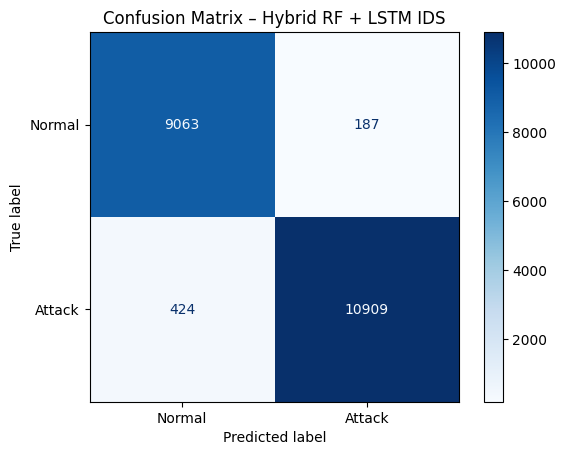

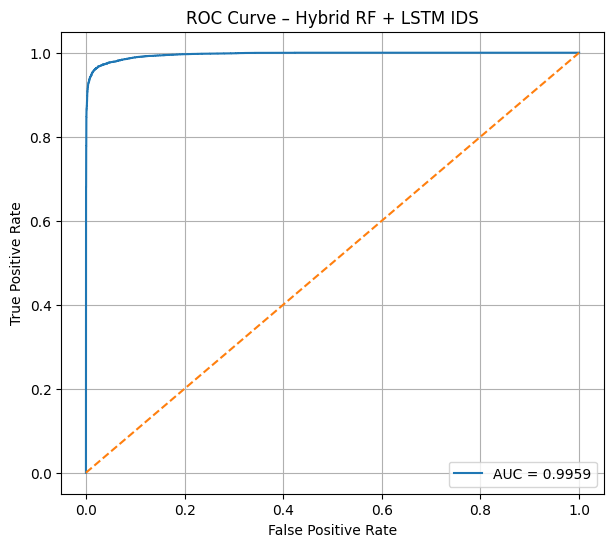

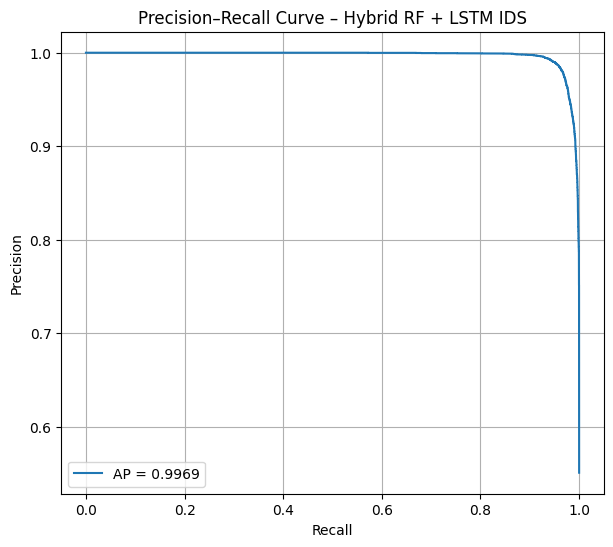

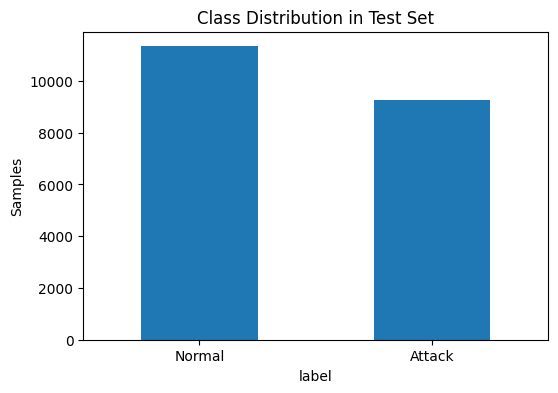

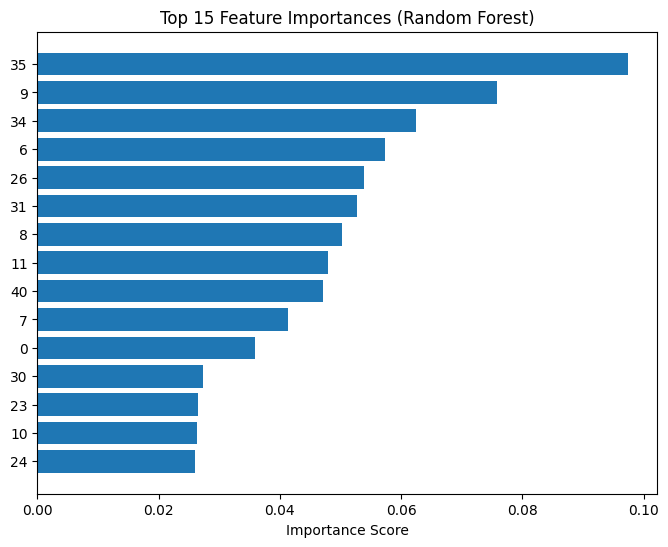

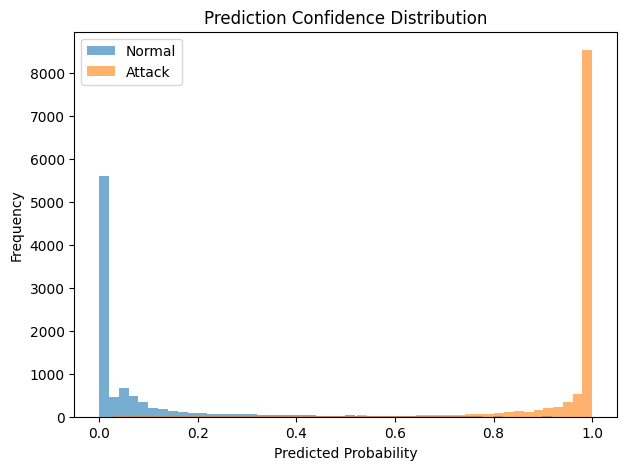

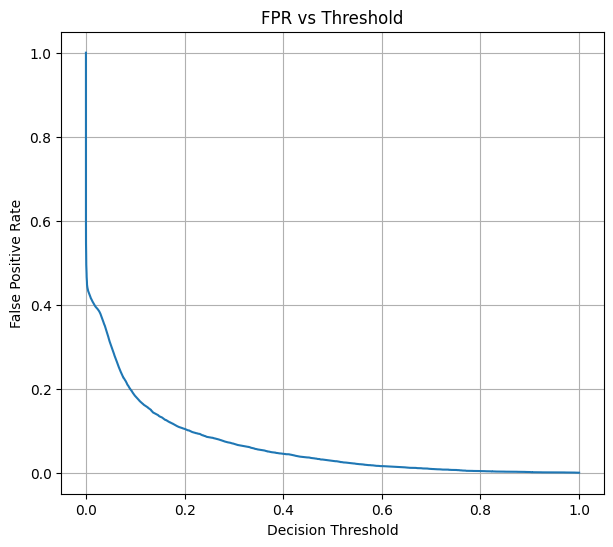

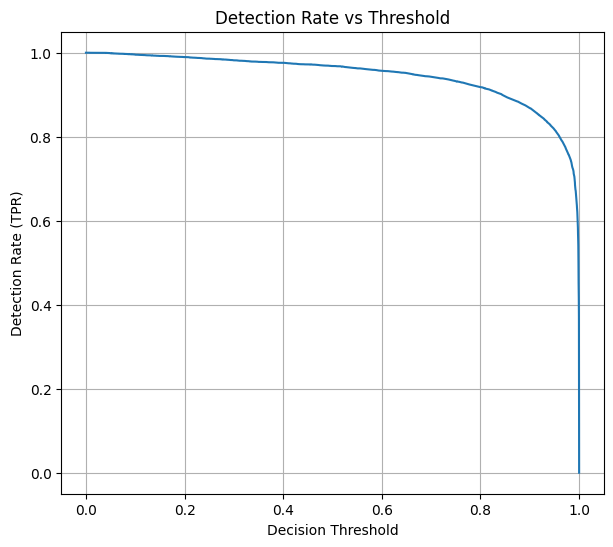


Classification Report Table:



,precision,recall,f1-score,support
0,0.955307,0.979784,0.967391,9250.000000
1,0.983147,0.962587,0.972758,11333.000000
accuracy,0.970315,0.970315,0.970315,0.970315
macro avg,0.969227,0.971185,0.970075,20583.000000
weighted avg,0.970636,0.970315,0.970346,20583.000000


In [19]:
# ==============================
# JOURNAL-READY VISUALIZATIONS
# SINGLE CELL
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

# ---------- 1. CONFUSION MATRIX ----------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"])

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix – Hybrid RF + LSTM IDS")
plt.show()

# ---------- 2. ROC CURVE ----------
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Hybrid RF + LSTM IDS")
plt.legend()
plt.grid(True)
plt.show()

# ---------- 3. PRECISION-RECALL CURVE ----------
precision, recall, _ = precision_recall_curve(y_test, final_probs)
ap = average_precision_score(y_test, final_probs)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Hybrid RF + LSTM IDS")
plt.legend()
plt.grid(True)
plt.show()

# ---------- 4. CLASS DISTRIBUTION ----------
plt.figure(figsize=(6,4))
y_test.value_counts().plot(kind='bar')
plt.xticks([0,1], ["Normal", "Attack"], rotation=0)
plt.ylabel("Samples")
plt.title("Class Distribution in Test Set")
plt.show()

# ---------- 5. FEATURE IMPORTANCE (Random Forest) ----------
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

# ---------- 6. PROBABILITY DISTRIBUTION ----------
plt.figure(figsize=(7,5))
plt.hist(final_probs[y_test==0], bins=50, alpha=0.6, label="Normal")
plt.hist(final_probs[y_test==1], bins=50, alpha=0.6, label="Attack")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()

# ---------- 7. THRESHOLD vs FALSE POSITIVE RATE ----------
plt.figure(figsize=(7,6))
plt.plot(thresholds, fpr)
plt.xlabel("Decision Threshold")
plt.ylabel("False Positive Rate")
plt.title("FPR vs Threshold")
plt.grid(True)
plt.show()

# ---------- 8. THRESHOLD vs DETECTION RATE ----------
plt.figure(figsize=(7,6))
plt.plot(thresholds, tpr)
plt.xlabel("Decision Threshold")
plt.ylabel("Detection Rate (TPR)")
plt.title("Detection Rate vs Threshold")
plt.grid(True)
plt.show()

# ---------- 9. CLASSIFICATION REPORT (TABLE) ----------
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("\nClassification Report Table:\n")
display(df_report)



================ MODEL RESULTS ================

Decision Tree
Accuracy: 0.8924153506595719
              precision    recall  f1-score   support

           0       0.76      0.97      0.85     56000
           1       0.98      0.86      0.92    119341

    accuracy                           0.89    175341
   macro avg       0.87      0.91      0.88    175341
weighted avg       0.91      0.89      0.90    175341


Random Forest (RF)
Accuracy: 0.8994359562224465
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341


Fast Random Forest (FRF)
Accuracy: 0.8974683616495857
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.86      0

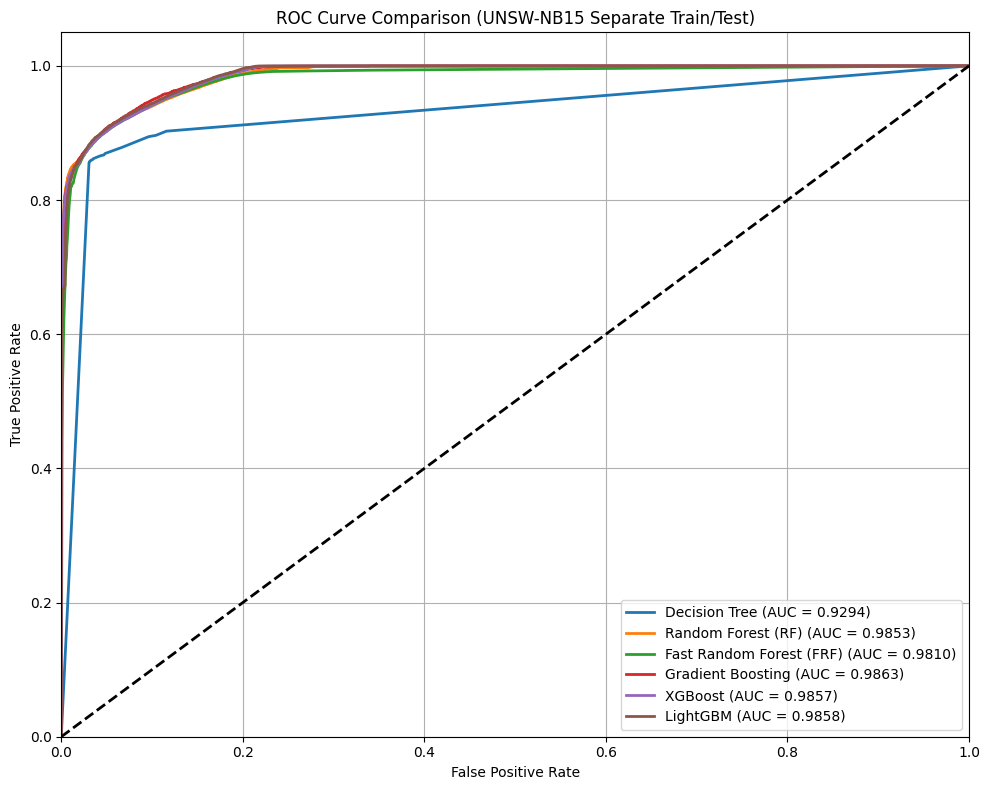

In [21]:
# ==============================
# ROC Curve – Separate Train/Test
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

# =====================================
# 1. Load Dataset (Separate Files)
# =====================================
train_path = r"datasets\UNSW_NB15_training-set.csv"
test_path  = r"datasets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# =====================================
# 2. Drop Non-Useful Columns
# =====================================
drop_cols = ['id', 'attack_cat']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# =====================================
# 3. Encode Categorical Features (Safe)
# =====================================
categorical_cols = train_df.select_dtypes(include='object').columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# =====================================
# 4. Split Features & Target
# =====================================
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# =====================================
# 5. Feature Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# =====================================
# 6. Handle Class Imbalance (TRAIN ONLY)
# =====================================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# =====================================
# 7. Define Models
# =====================================
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20,
        random_state=42
    ),

    "Random Forest (RF)": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ),

    "Fast Random Forest (FRF)": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=10,
        random_state=42
    )
}

# =====================================
# 8. Train Models & Plot ROC Curves
# =====================================
plt.figure(figsize=(10, 8))

print("\n================ MODEL RESULTS ================")

for name, model in models.items():
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # ROC Curve
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

# =====================================
# 9. ROC Plot Formatting
# =====================================
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (UNSW-NB15 Separate Train/Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
